# Modelagem

Neste primeiro notebook de modelagem, cria-se um modelo de séries temporais usando-se o mínimo de limpeza dos dados.


- Links uteis:

1 - https://theairlab.org/alfa-dataset/ (contém informações sobre o status do vôo.)

# Modelo básico


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Parâmetros

In [2]:
DATA_FILE = '../data/02_intermediate/carbonZ_2018-07-18-15-53-31_1_engine_failure_sem_cols_duplicadas.csv'

# Funções

In [3]:
# 1. Preparação dos Dados
def create_windows(df, window_size, features, target_col):
    X, y = [], []
    data = df[features].values
    labels = df[target_col].values
    
    for i in range(window_size, len(df)):
        # Pegamos as últimas 'window_size' linhas e achatamos em um vetor longo
        window = data[i-window_size:i].flatten()
        X.append(window)
        y.append(labels[i])
        
    return np.array(X), np.array(y)

# Modelagem

In [4]:
df = pd.read_csv(DATA_FILE)

In [5]:
df

,timestamp,target_fault,dev_path_y,dev_path_z,ctrl_yaw_rate,nav_heading,alt_global,vel_z_local,alt_gps_fix,vel_x_gps,...,groundspeed_hud,wind_x,wind_y,wind_z,err_pitch,err_roll,err_vel_x,err_vel_y,err_vel_z,err_yaw
0,0.000000,0.0,124.178470,12.752701,0.207062,76.30,347.412387,-2.72,350.452363,18.355274,...,17.793749,3.244974,6.901174,0.0,-6.997611,-33.136244,15.970607,-17.793726,2.984414,-120.351761
1,0.004599,0.0,124.178470,12.752701,0.207062,76.30,347.412387,-2.72,350.452363,18.355274,...,17.793749,3.244974,6.901174,0.0,-6.997611,-33.136244,15.839832,-17.614655,3.064302,-120.351761
2,0.004864,0.0,124.178470,12.752701,0.207062,76.30,347.412387,-2.72,350.452363,18.355274,...,17.793749,3.244974,6.901174,0.0,-6.997611,-33.136244,15.839832,-17.614655,3.064302,-120.351761
3,0.005244,0.0,124.178470,12.752701,0.207062,76.30,347.412387,-2.72,350.452363,18.355274,...,17.793749,3.244974,6.901174,0.0,-6.997611,-33.136244,15.839832,-17.614655,3.064302,-120.351761
4,0.007918,0.0,124.178470,12.752701,0.207062,76.30,347.412387,-2.72,350.452363,18.355274,...,17.793749,3.244974,6.901174,0.0,-6.997611,-33.136244,15.839832,-17.614655,3.064302,-120.351761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25989,131.375018,1.0,8.337481,21.670137,2.958271,283.02,338.493609,1.48,338.653619,-10.399391,...,10.047353,-0.410417,1.880182,0.0,9.765117,-1.199749,-0.264460,-5.924379,-1.284375,4.496452
25990,131.375844,1.0,8.337481,21.670137,2.958271,283.02,338.493609,1.48,338.653619,-10.399391,...,10.047353,-0.410417,1.880182,0.0,9.765117,-1.199749,-0.264460,-5.924379,-1.284375,4.496452
25991,131.377763,1.0,8.337481,21.670137,2.958271,283.02,338.493609,1.48,338.653619,-10.399391,...,10.047353,-0.410417,1.880182,0.0,9.765117,-1.199749,-0.264460,-5.924379,-1.284375,4.496452
25992,131.385300,1.0,8.337481,21.670137,2.958271,283.02,338.493609,1.48,338.653619,-10.399391,...,10.047353,-0.410417,1.880182,0.0,9.765117,-1.199749,-0.264460,-5.924379,-1.284375,4.496452


In [6]:
# Vamos definir o tamanho da janela (ex: 20 amostras = 0.2s de história)
window_size = 20
target_col = 'target_fault'
features = [c for c in df.columns if c not in [target_col, 'timestamp']]

In [7]:
X, y = create_windows(df, window_size, features, target_col)

In [8]:
X

array([[ 124.17846993,   12.75270081,    0.20706232, ...,  -17.38635254,
           3.12066054, -120.35176086],
       [ 124.17846993,   12.75270081,    0.20706232, ...,  -17.38635254,
           3.12066054, -120.35176086],
       [ 124.17846993,   12.75270081,    0.20706232, ...,  -17.38635254,
           3.12066054, -120.35176086],
       ...,
       [   8.33748129,   21.67013741,    2.9582711 , ...,   -5.92437935,
          -1.28437495,    4.49645233],
       [   8.33748129,   21.67013741,    2.9582711 , ...,   -5.92437935,
          -1.28437495,    4.49645233],
       [   8.33748129,   21.67013741,    2.9582711 , ...,   -5.92437935,
          -1.28437495,    4.49645233]], shape=(25974, 1040))

Aviso: index 0 is out of bounds for axis 0 with size 0

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.59      1.00      0.74      4573
         1.0       0.00      0.00      0.00      3220

    accuracy                           0.59      7793
   macro avg       0.29      0.50      0.37      7793
weighted avg       0.34      0.59      0.43      7793



/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


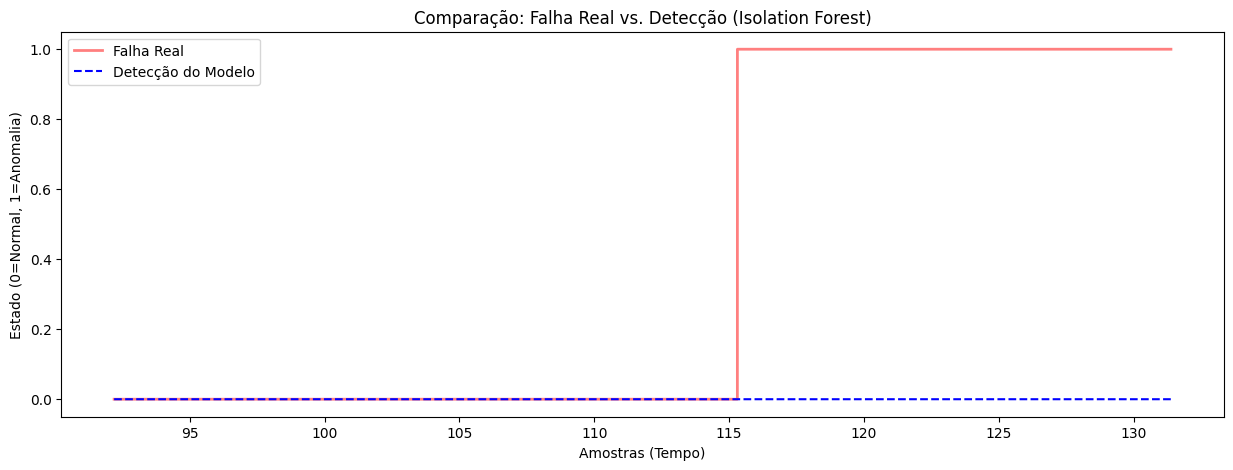

In [9]:
# 3. Divisão de Treino e Teste
# Importante: Treinamos APENAS com dados onde target_fault == 0
# Vamos usar os primeiros 70% do voo, que sabemos ser nominal
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

# 4. Treinamento do Isolation Forest
# contamination: estimativa de anomalias no treino. Como o treino é nominal, 
# usamos um valor bem baixo (ex: 0.1%) apenas para robustez a ruído.
model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

test_timestamps = df['timestamp'].values[split + window_size:]

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(test_timestamps, y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(test_timestamps, y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()

Nenhuma anomalia encontrada.

# Selecionando as 10 features mais importantes - Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

# 1. Usar um modelo supervisionado rápido apenas para identificar relevância
# Aqui não precisamos de janelas, apenas os dados brutos linha a linha
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(df[features], df[target_col])

# 2. Criar um ranking das features
importances = pd.Series(rf_selector.feature_importances_, index=features)
top_features = importances.sort_values(ascending=False).head(10)

print("--- TOP 10 FEATURES MAIS RELEVANTES ---")
print(top_features)

# 3. Filtrar seu DataFrame para usar apenas essas 10
selected_features = top_features.index.tolist()
# Agora você pode rodar o Isolation Forest apenas com df_normalized[selected_features]

--- TOP 10 FEATURES MAIS RELEVANTES ---
aspd_hud           0.109759
aspd_meas          0.077940
alt_error          0.072027
alt_hud            0.071675
alt_global         0.063311
yaw_rate_target    0.056511
pos_z_local        0.049208
alt_gps_fix        0.039174
dev_path_z         0.037288
wind_y             0.035171
dtype: float64


- aspd_hud é a Velocidade do Ar consolidada que o sistema de voo apresenta para o piloto (ou operador) no painel principal. HUD refere-se a Heads-Up Display (Monitor de Transparência).

- yaw_rate_target: O Yaw (Guinada) é o movimento de girar o nariz do avião para a esquerda ou para a direita, como se o avião estivesse "olhando" para os lados sem inclinar as asas.

In [11]:
selected_features

['aspd_hud',
 'aspd_meas',
 'alt_error',
 'alt_hud',
 'alt_global',
 'yaw_rate_target',
 'pos_z_local',
 'alt_gps_fix',
 'dev_path_z',
 'wind_y']

In [12]:
# Criar a lista final de colunas que desejamos manter
cols_to_keep = selected_features + [target_col]

# 2. Filtrar o DataFrame original apenas com essas colunas
df_rf = df[cols_to_keep].copy()

print(f"Novo DataFrame criado com {df_rf.shape[1]} colunas.")
print(df_rf.head())

Novo DataFrame criado com 11 colunas.
    aspd_hud  aspd_meas  alt_error     alt_hud  alt_global  yaw_rate_target  \
0  18.193935  18.193935      -2.14  382.419983  347.412387       -18.193935   
1  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
2  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
3  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
4  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   

   pos_z_local  alt_gps_fix  dev_path_z    wind_y  target_fault  
0    37.247299   350.452363   12.752701  6.901174           0.0  
1    37.247299   350.452363   12.752701  6.901174           0.0  
2    37.247299   350.452363   12.752701  6.901174           0.0  
3    37.247299   350.452363   12.752701  6.901174           0.0  
4    37.247299   350.452363   12.752701  6.901174           0.0  


In [13]:
X, y = create_windows(df_rf, window_size, selected_features, target_col)

In [14]:
X

array([[ 18.19393539,  18.19393539,  -2.13999987, ..., 350.45236297,
         12.75270081,   6.90117376],
       [ 18.19393539,  18.21097946,  -2.13999987, ..., 350.45236297,
         12.75270081,   6.90117376],
       [ 18.19393539,  18.21097946,  -2.13999987, ..., 350.45236297,
         12.75270081,   6.90117376],
       ...,
       [ 11.43355846,  11.62463856,   7.28999996, ..., 338.65361908,
         21.67013741,   1.88018177],
       [ 11.43355846,  11.62463856,   7.28999996, ..., 338.65361908,
         21.67013741,   1.88018177],
       [ 11.43355846,  11.62463856,   7.28999996, ..., 338.65361908,
         21.67013741,   1.88018177]], shape=(25974, 200))

Aviso: index 0 is out of bounds for axis 0 with size 0

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.59      1.00      0.74      4573
         1.0       0.00      0.00      0.00      3220

    accuracy                           0.59      7793
   macro avg       0.29      0.50      0.37      7793
weighted avg       0.34      0.59      0.43      7793



/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/renato/projetos/capacitacao-avancada/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


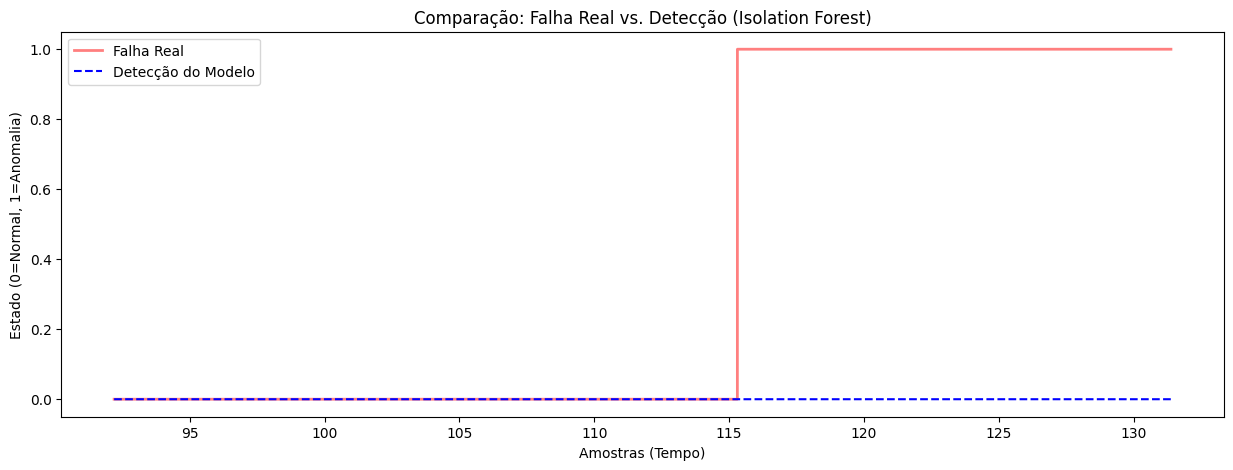

In [16]:
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

test_timestamps = df['timestamp'].values[split + window_size:]

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(test_timestamps, y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(test_timestamps, y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()

# Seleção manual olhando os gráficos 

In [18]:
df.columns

Index(['timestamp', 'target_fault', 'dev_path_y', 'dev_path_z',
       'ctrl_yaw_rate', 'nav_heading', 'alt_global', 'vel_z_local',
       'alt_gps_fix', 'vel_x_gps', 'vel_y_gps', 'mag_x', 'mag_y', 'mag_z',
       'vel_x_odom', 'vel_y_odom', 'vel_z_odom', 'pos_x_local', 'pos_y_local',
       'pos_z_local', 'vel_x_twist', 'vel_y_twist', 'vel_z_twist', 'aspd_cmd',
       'aspd_meas', 'alt_error', 'aspd_error', 'nav_dist_wp',
       'nav_error_xtrack', 'pitch_cmd', 'pitch_meas', 'roll_cmd', 'roll_meas',
       'vel_x_des', 'vel_y_des', 'vel_z_des', 'vel_x_meas', 'vel_y_meas',
       'vel_z_meas', 'yaw_cmd', 'yaw_meas', 'yaw_rate_target', 'aspd_hud',
       'alt_hud', 'groundspeed_hud', 'wind_x', 'wind_y', 'wind_z', 'err_pitch',
       'err_roll', 'err_vel_x', 'err_vel_y', 'err_vel_z', 'err_yaw'],
      dtype='str')

In [19]:
important_cols = ['dev_path_z',
                      'vel_x_odom',
                      'vel_z_odom',
                      'pos_z_local',
                      'aspd_meas',
                      'alt_error',
                      'aspd_error',
                      'aspd_hud',
                      'alt_hud',
                      'groundspeed_hud'
                      ]

In [20]:
# Criar a lista final de colunas que desejamos manter
cols_to_keep = important_cols + [target_col]

# 2. Filtrar o DataFrame original apenas com essas colunas
df_manual_crafted = df[cols_to_keep].copy()

print(f"Novo DataFrame criado com {df_manual_crafted.shape[1]} colunas.")
print(df_rf.head())

Novo DataFrame criado com 11 colunas.
    aspd_hud  aspd_meas  alt_error     alt_hud  alt_global  yaw_rate_target  \
0  18.193935  18.193935      -2.14  382.419983  347.412387       -18.193935   
1  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
2  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
3  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
4  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   

   pos_z_local  alt_gps_fix  dev_path_z    wind_y  target_fault  
0    37.247299   350.452363   12.752701  6.901174           0.0  
1    37.247299   350.452363   12.752701  6.901174           0.0  
2    37.247299   350.452363   12.752701  6.901174           0.0  
3    37.247299   350.452363   12.752701  6.901174           0.0  
4    37.247299   350.452363   12.752701  6.901174           0.0  


In [21]:
X, y = create_windows(df_manual_crafted, window_size, important_cols, target_col)

In [22]:
X

array([[ 12.75270081,  17.89910005,   1.46697282, ...,  18.19393539,
        382.41998291,  17.79374886],
       [ 12.75270081,  17.89910005,   1.46697282, ...,  18.19393539,
        382.41998291,  17.79374886],
       [ 12.75270081,  17.89910005,   1.46697282, ...,  18.19393539,
        382.41998291,  17.79374886],
       ...,
       [ 21.67013741,   9.88338434,  -3.18753066, ...,  11.31165123,
        372.8999939 ,  10.04735279],
       [ 21.67013741,   9.88338434,  -3.18753066, ...,  11.31165123,
        372.8999939 ,  10.04735279],
       [ 21.67013741,   9.88338434,  -3.18753066, ...,  11.31165123,
        372.8999939 ,  10.04735279]], shape=(25974, 200))

--- RESULTADO DA DETECÇÃO ---
A falha foi detectada com uma latência de: 21.290 segundos

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.68      1.00      0.81      4573
         1.0       1.00      0.34      0.51      3220

    accuracy                           0.73      7793
   macro avg       0.84      0.67      0.66      7793
weighted avg       0.81      0.73      0.69      7793



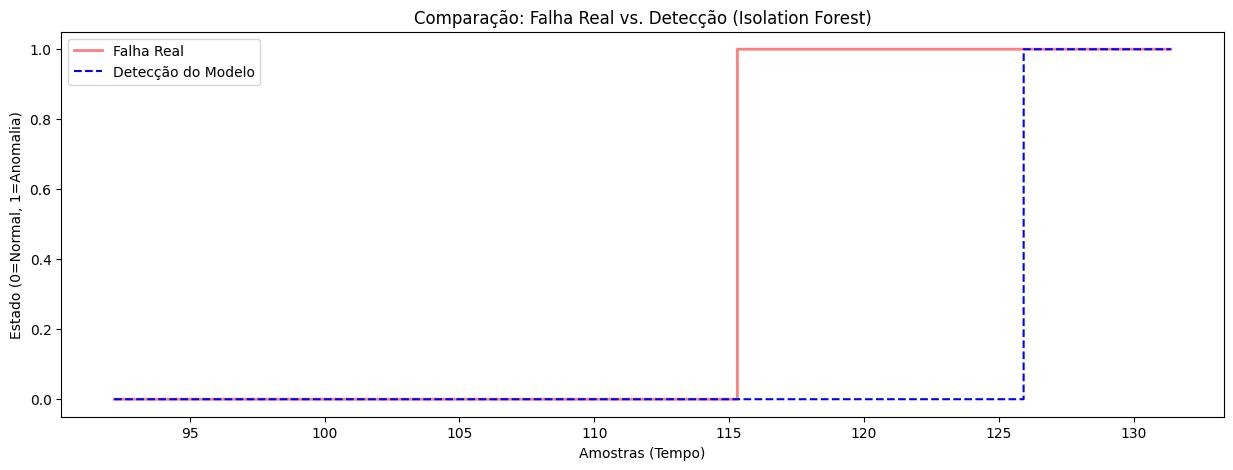

In [23]:
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

test_timestamps = df['timestamp'].values[split + window_size:]

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(test_timestamps, y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(test_timestamps, y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()

# Seleção manual 2

In [24]:
df.columns

Index(['timestamp', 'target_fault', 'dev_path_y', 'dev_path_z',
       'ctrl_yaw_rate', 'nav_heading', 'alt_global', 'vel_z_local',
       'alt_gps_fix', 'vel_x_gps', 'vel_y_gps', 'mag_x', 'mag_y', 'mag_z',
       'vel_x_odom', 'vel_y_odom', 'vel_z_odom', 'pos_x_local', 'pos_y_local',
       'pos_z_local', 'vel_x_twist', 'vel_y_twist', 'vel_z_twist', 'aspd_cmd',
       'aspd_meas', 'alt_error', 'aspd_error', 'nav_dist_wp',
       'nav_error_xtrack', 'pitch_cmd', 'pitch_meas', 'roll_cmd', 'roll_meas',
       'vel_x_des', 'vel_y_des', 'vel_z_des', 'vel_x_meas', 'vel_y_meas',
       'vel_z_meas', 'yaw_cmd', 'yaw_meas', 'yaw_rate_target', 'aspd_hud',
       'alt_hud', 'groundspeed_hud', 'wind_x', 'wind_y', 'wind_z', 'err_pitch',
       'err_roll', 'err_vel_x', 'err_vel_y', 'err_vel_z', 'err_yaw'],
      dtype='str')

In [25]:
case_4_cols = [
    'aspd_meas',       # O primeiro a cair
    'aspd_error',      # Explode quando o motor para
    'err_pitch',       # (A que criamos) O drone tenta subir o bico para não cair
    'err_vel_x',       # (A que criamos) O comando quer velocidade, o sensor mostra queda
    'pitch_meas',      # A inclinação muda drasticamente para tentar manter o planeio
    'yaw_rate_target', # O controlador de voo "se desespera" para manter o rumo
    'aspd_hud'         # Confirmação da velocidade filtrada
]

In [26]:
# Criar a lista final de colunas que desejamos manter
cols_to_keep = case_4_cols + [target_col]

# 2. Filtrar o DataFrame original apenas com essas colunas
df_manual_2 = df[cols_to_keep].copy()

print(f"Novo DataFrame criado com {df_manual_2.shape[1]} colunas.")
print(df_rf.head())

Novo DataFrame criado com 8 colunas.
    aspd_hud  aspd_meas  alt_error     alt_hud  alt_global  yaw_rate_target  \
0  18.193935  18.193935      -2.14  382.419983  347.412387       -18.193935   
1  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
2  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
3  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   
4  18.193935  18.210979      -2.14  382.419983  347.412387       -18.210979   

   pos_z_local  alt_gps_fix  dev_path_z    wind_y  target_fault  
0    37.247299   350.452363   12.752701  6.901174           0.0  
1    37.247299   350.452363   12.752701  6.901174           0.0  
2    37.247299   350.452363   12.752701  6.901174           0.0  
3    37.247299   350.452363   12.752701  6.901174           0.0  
4    37.247299   350.452363   12.752701  6.901174           0.0  


In [27]:
X, y = create_windows(df_manual_2, window_size, case_4_cols, target_col)

In [28]:
X

array([[  18.19393539, -221.09794617,   -6.99761128, ...,    8.54761124,
         -18.00628471,   18.19393539],
       [  18.21097946, -221.09794617,   -6.99761128, ...,    8.54761124,
         -18.00628471,   18.19393539],
       [  18.21097946, -221.09794617,   -6.99761128, ...,    8.54761124,
         -18.00628471,   18.19393539],
       ...,
       [  11.62463856, -248.26947022,    9.78511715, ...,    7.71488285,
         -11.31165123,   11.31165123],
       [  11.62463856, -248.26947022,    9.78511715, ...,    7.71488285,
         -11.31165123,   11.31165123],
       [  11.62463856, -248.26947022,    9.78511715, ...,    7.71488285,
         -11.31165123,   11.31165123]], shape=(25974, 140))

--- RESULTADO DA DETECÇÃO ---
A falha foi detectada com uma latência de: 3.180 segundos

Relatório de Classificação (Conjunto de Teste):
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.86      4573
         1.0       0.81      0.77      0.79      3220

    accuracy                           0.83      7793
   macro avg       0.82      0.82      0.82      7793
weighted avg       0.83      0.83      0.83      7793



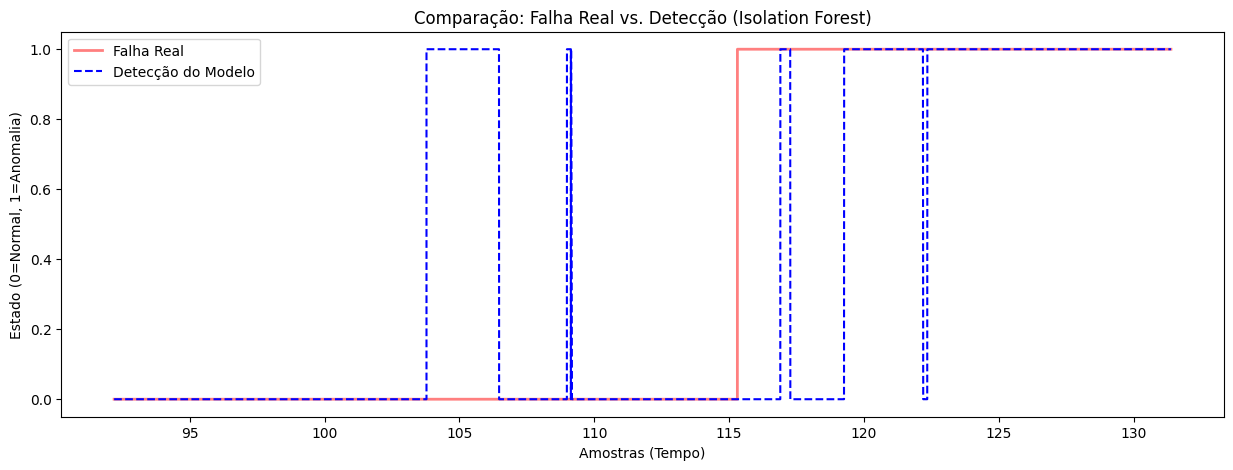

In [31]:
split = int(len(X) * 0.7)
X_train = X[:split] 
y_train = y[:split] # Apenas para conferência, o modelo não usa isso no .fit()

X_test = X[split:]
y_test = y[split:]

model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
model.fit(X_train)

# 5. Predição
# O Isolation Forest retorna -1 para anomalia e 1 para normal.
y_pred_raw = model.predict(X_test)

# Convertendo para o nosso padrão: 0 para normal, 1 para anomalia
y_pred = np.where(y_pred_raw == -1, 1, 0)

# 6. Cálculo da Latência de Detecção
try:
    # Índice da primeira falha real no conjunto de teste
    real_fault_indices = np.where(y_test == 1)[0]
    if len(real_fault_indices) == 0:
        raise ValueError("Não há falhas reais no conjunto de teste.")
        
    real_fault_idx = real_fault_indices[0]
    
    # Busca a primeira detecção (1) a partir do momento da falha real
    pred_fault_idx = np.where((y_pred == 1) & (np.arange(len(y_pred)) >= real_fault_idx))[0][0]
    
    latency = (pred_fault_idx - real_fault_idx) * 0.01 # 100Hz
    print(f"--- RESULTADO DA DETECÇÃO ---")
    print(f"A falha foi detectada com uma latência de: {latency:.3f} segundos")
except (IndexError, ValueError) as e:
    print(f"Aviso: {e}")

# 7. Relatório de Desempenho
print("\nRelatório de Classificação (Conjunto de Teste):")
print(classification_report(y_test, y_pred))

test_timestamps = df['timestamp'].values[split + window_size:]

# 8. Visualização dos Resultados
plt.figure(figsize=(15, 5))
plt.plot(test_timestamps, y_test, label='Falha Real', color='red', alpha=0.5, linewidth=2)
plt.plot(test_timestamps, y_pred, label='Detecção do Modelo', color='blue', linestyle='--')
plt.title('Comparação: Falha Real vs. Detecção (Isolation Forest)')
plt.xlabel('Amostras (Tempo)')
plt.ylabel('Estado (0=Normal, 1=Anomalia)')
plt.legend()
plt.show()